In [2]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

from scipy.cluster.hierarchy import dendrogram, linkage

import joblib
import os

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('All libraries imported successfully')

All libraries imported successfully


In [3]:
df = pd.read_csv('../data/dataCleaned.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nPrice stats:")
print(df['price'].describe())
df.head()

Shape: (96125, 9)

Columns: ['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'mpg', 'engineSize', 'brand']

Price stats:
count    96125.000000
mean     16567.395984
std       9472.798476
min       1000.000000
25%       9998.000000
50%      14200.000000
75%      20490.000000
max      99950.000000
Name: price, dtype: float64


,model,year,price,transmission,mileage,fuelType,mpg,engineSize,brand
0,A1,2017,12500,Manual,15735,Petrol,55.4,1.4,Audi
1,A6,2016,16500,Automatic,36203,Diesel,64.2,2.0,Audi
2,A1,2016,11000,Manual,29946,Petrol,55.4,1.4,Audi
3,A4,2017,16800,Automatic,25952,Diesel,67.3,2.0,Audi
4,A3,2019,17300,Manual,1998,Petrol,49.6,1.0,Audi


In [5]:
print('=' * 60)
print('Dataset Overview')
print('=' * 60)

print(f'\n Dataset Dimensions: {df.shape[0]} rows x {df.shape[1]} columns \n')

print('Data Types:')
print(df.dtypes)

print('\n Missing Values by Column:')
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else 'No missing values found.')

print('\n Descriptive Statistics:')
df.describe()

Dataset Overview

 Dataset Dimensions: 96125 rows x 9 columns 

Data Types:
model               str
year              int64
price             int64
transmission        str
mileage           int64
fuelType            str
mpg             float64
engineSize      float64
brand               str
dtype: object

 Missing Values by Column:
No missing values found.

 Descriptive Statistics:


,year,price,mileage,mpg,engineSize
count,96125.000000,96125.000000,96125.000000,96125.000000,96125.000000
mean,2017.035932,16567.395984,23618.443901,55.115521,1.665363
std,2.084389,9472.798476,20963.278605,13.434603,0.544939
min,1998.000000,1000.000000,100.000000,0.300000,1.000000
25%,2016.000000,9998.000000,8116.000000,47.100000,1.200000
50%,2017.000000,14200.000000,18066.000000,54.300000,1.600000
75%,2019.000000,20490.000000,32859.000000,62.800000,2.000000
max,2020.000000,99950.000000,241565.000000,470.800000,6.000000


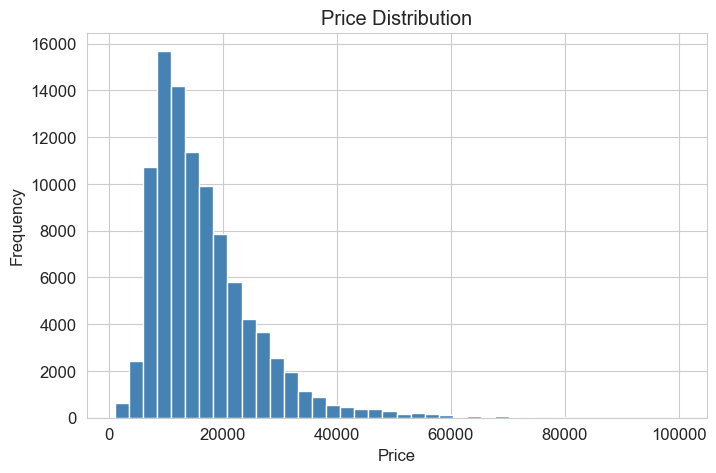

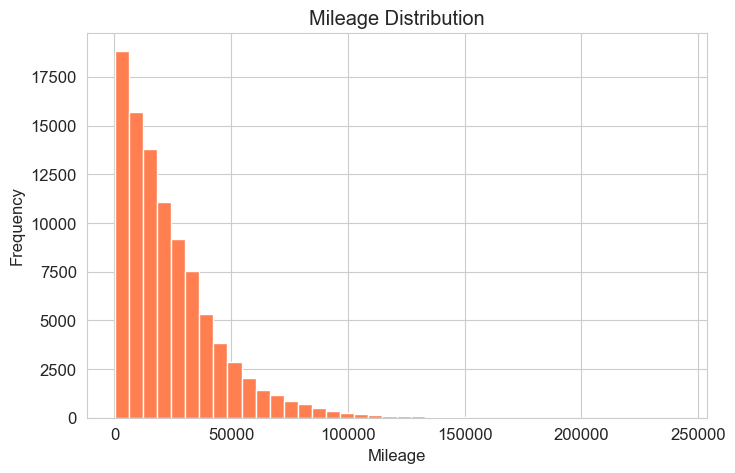

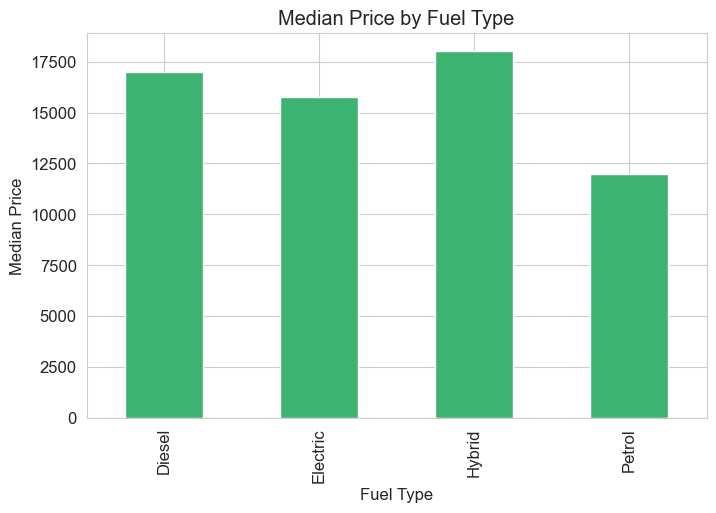

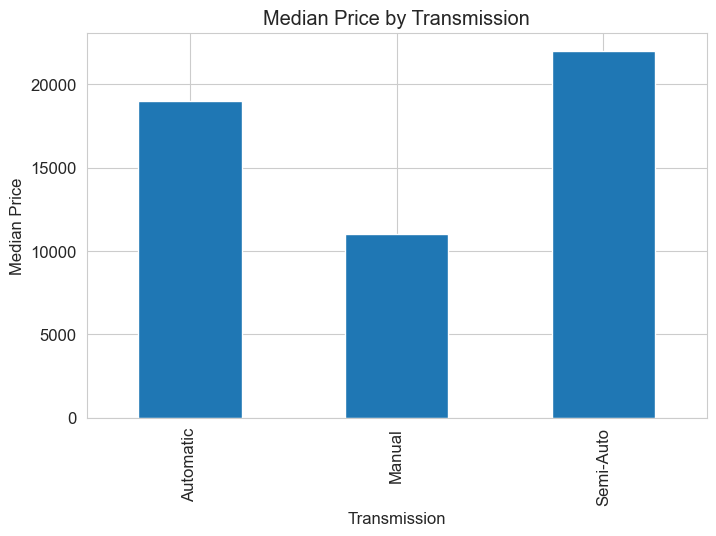

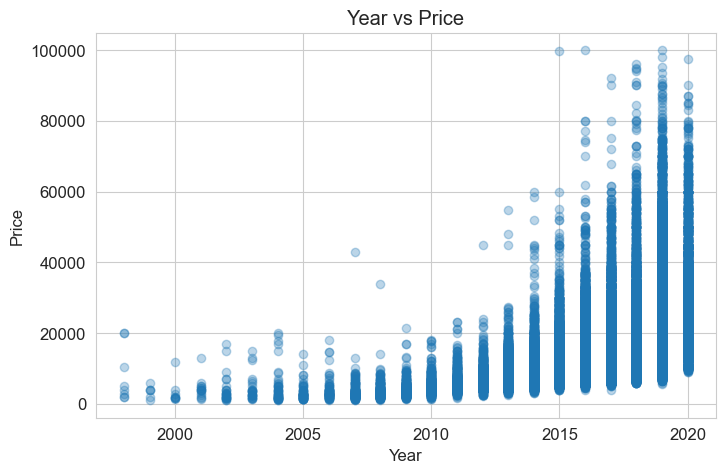

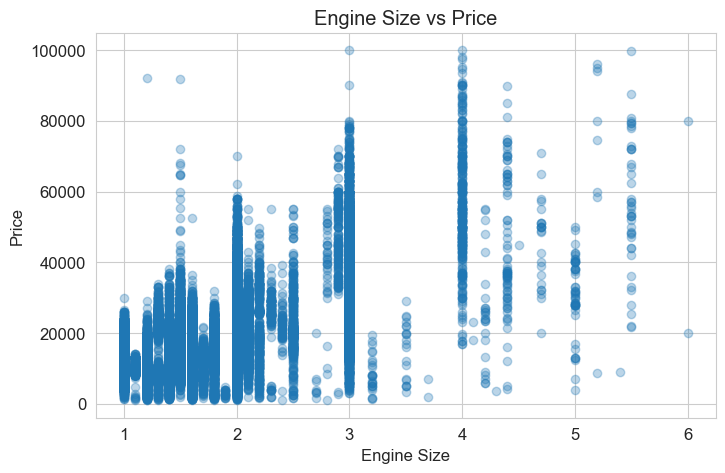

In [11]:
plt.figure(figsize=(8,5))
plt.hist(df['price'], bins=40, color='steelblue', edgecolor='white')
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(8,5))
plt.hist(df['mileage'], bins=40, color='coral', edgecolor='white')
plt.title('Mileage Distribution')
plt.xlabel('Mileage')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(8,5))

df.groupby('fuelType')['price'].median().plot(
    kind='bar',
    color='mediumseagreen'
)

plt.title('Median Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Median Price')
plt.show()

plt.figure(figsize=(8,5))

df.groupby('transmission')['price'].median().plot(
    kind='bar'
)

plt.title('Median Price by Transmission')
plt.xlabel('Transmission')
plt.ylabel('Median Price')
plt.show()

plt.figure(figsize=(8,5))

plt.scatter(
    df['year'],
    df['price'],
    alpha=0.3
)

plt.title('Year vs Price')
plt.xlabel('Year')
plt.ylabel('Price')
plt.show()

plt.figure(figsize=(8,5))

plt.scatter(
    df['engineSize'],
    df['price'],
    alpha=0.3
)

plt.title('Engine Size vs Price')
plt.xlabel('Engine Size')
plt.ylabel('Price')
plt.show()

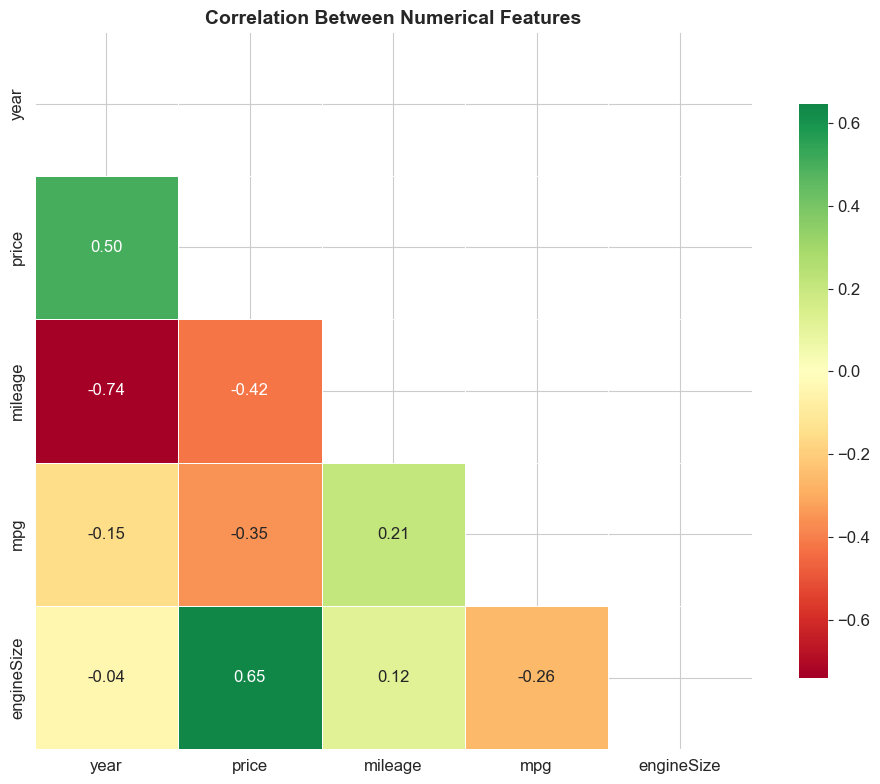

Graph saved: plots/correlation_heatmap.png


In [13]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(10, 8))

corr_matrix = df[numeric_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)

plt.title('Correlation Between Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()

plt.savefig(
    'plots/correlation_heatmap.png', 
    dpi=150, 
    bbox_inches='tight'
)

plt.show()
print('Graph saved: plots/correlation_heatmap.png')

In [14]:
print('=' * 60)
print('FEATURE SELECTION FOR CLUSTERING')
print('=' * 60)

feature_justification = {
    'year': 'Production year - newer vehicles tend to have higher market value',
    'mileage': 'Mileage - indicates vehicle usage and wear',
    'engineSize': 'Engine size - related to performance and vehicle category',
    'mpg': 'Fuel efficiency - reflects operating costs',
    'price': 'Market value - helps identify natural market segments'
}

print('\nSelected Features and Justification:')

for feat, reason in feature_justification.items():
    print(f'  {feat:12s} -> {reason}')

print('\nExcluded Features:')

print('  model -> High-cardinality categorical feature')
print('  brand -> Categorical feature, excluded from initial clustering')
print('  transmission -> Will be considered separately if encoded')
print('  fuelType -> Will be considered separately if encoded')

NUMERICAL_FEATURES = [
    'year',
    'mileage',
    'engineSize',
    'mpg',
    'price'
]

print(f'\nNumber of numerical features: {len(NUMERICAL_FEATURES)}')
print(NUMERICAL_FEATURES)

FEATURE SELECTION FOR CLUSTERING

Selected Features and Justification:
  year         -> Production year - newer vehicles tend to have higher market value
  mileage      -> Mileage - indicates vehicle usage and wear
  engineSize   -> Engine size - related to performance and vehicle category
  mpg          -> Fuel efficiency - reflects operating costs
  price        -> Market value - helps identify natural market segments

Excluded Features:
  model -> High-cardinality categorical feature
  brand -> Categorical feature, excluded from initial clustering
  transmission -> Will be considered separately if encoded
  fuelType -> Will be considered separately if encoded

Number of numerical features: 5
['year', 'mileage', 'engineSize', 'mpg', 'price']


In [17]:
df = df.copy()

print('Handling missing values')
initial_shape = df.shape

df = df.copy()

df['car_age'] = 2020 - df['year']

NUMERICAL_FEATURES = ['car_age','mileage','mpg','engineSize']
CATEGORICAL_FEATURES = ['transmission', 'fuelType', 'brand']
TARGET = 'price'

for col in NUMERICAL_FEATURES:
    n_null = df[col].isnull().sum()
    if n_null > 0:
        df[col] = df[col].fillna(df[col].median())
        print(f'{col}: {n_null} null values filled with median')

for col in CATEGORICAL_FEATURES:
    n_null = df[col].isnull().sum()
    if n_null > 0:
        df[col] = df[col].fillna(df[col].mode()[0])
        print(f'{col}: {n_null} null values filled with mode')

df.dropna(subset=NUMERICAL_FEATURES + CATEGORICAL_FEATURES + [TARGET], inplace=True)

print(f'Dataset after cleaning: {initial_shape} -> {df.shape}')

print('\n Encoding categorical with One-Hot Encoding')

df_encoded = pd.get_dummies(
    df,
    columns=CATEGORICAL_FEATURES,
    drop_first=True
)

encoded_cat = [
    col for col in df_encoded.columns
    if col.startswith('transmission_') 
    or col.startswith('fuelType_') 
    or col.startswith('brand_')
]

ALL_FEATURES = NUMERICAL_FEATURES + encoded_cat

X = df_encoded[ALL_FEATURES].copy()

y_true = df_encoded[TARGET].copy()

print(f'\nX features shape: {X.shape}')
print(f'y_true shape: {y_true.shape}')
print(f'Numerical features: {NUMERICAL_FEATURES}')
print(f'Encoded categorical features: {len(encoded_cat)}')

X.head()

Handling missing values
Dataset after cleaning: (96125, 12) -> (96125, 13)

 Encoding categorical with One-Hot Encoding

X features shape: (96125, 20)
y_true shape: (96125,)
Numerical features: ['car_age', 'mileage', 'mpg', 'engineSize']
Encoded categorical features: 16


,car_age,mileage,mpg,engineSize,transmission_encoded,fuelType_encoded,brand_encoded,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Petrol,brand_Bmw,brand_Ford,brand_Hyundai,brand_Mercedes,brand_Skoda,brand_Toyota,brand_Vauxhall,brand_Volkswagen
0,3,15735,55.4,1.4,1,3,0,True,False,False,False,True,False,False,False,False,False,False,False,False
1,4,36203,64.2,2.0,0,0,0,False,False,False,False,False,False,False,False,False,False,False,False,False
2,4,29946,55.4,1.4,1,3,0,True,False,False,False,True,False,False,False,False,False,False,False,False
3,3,25952,67.3,2.0,0,0,0,False,False,False,False,False,False,False,False,False,False,False,False,False
4,1,1998,49.6,1.0,1,3,0,True,False,False,False,True,False,False,False,False,False,False,False,False


In [19]:
print('Handling outliers using IQR clipping')

X_clean = X.copy()

for col in NUMERICAL_FEATURES:
    Q1 = X_clean[col].quantile(0.05)
    Q3 = X_clean[col].quantile(0.95)
    IQR = Q3 - Q1

    lower = Q1 - 2.5 * IQR
    upper = Q3 + 2.5 * IQR

    X_clean[col] = X_clean[col].clip(lower, upper)

print('Extreme outliers were capped using 5%-95% IQR clipping.')

print('\nStandardizing data using StandardScaler')
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=ALL_FEATURES,
    index=X_clean.index
)

print(f'Before standardization (car_age): mean={X_clean["car_age"].mean():.2f}, std={X_clean["car_age"].std():.2f}')
print(f'After standardization (car_age): mean={X_scaled_df["car_age"].mean():.4f}, std={X_scaled_df["car_age"].std():.4f}')

print(f'\nShape after preprocessing: {X_scaled.shape}')

price_quantiles = pd.qcut(
    y_true,
    q=4,
    labels=['Budget', 'Economy', 'Mid-Range', 'Premium']
)

y_price_category = price_quantiles.values

le_price = LabelEncoder()
y_encoded = le_price.fit_transform(y_price_category)
price_classes = le_price.classes_

print(f'\nReal price categories, used only for comparison: {list(price_classes)}')
print(pd.Series(y_price_category).value_counts())


Handling outliers using IQR clipping
Extreme outliers were capped using 5%-95% IQR clipping.

Standardizing data using StandardScaler
Before standardization (car_age): mean=2.96, std=2.08
After standardization (car_age): mean=0.0000, std=1.0000

Shape after preprocessing: (96125, 20)

Real price categories, used only for comparison: ['Budget', 'Economy', 'Mid-Range', 'Premium']
Budget       24277
Mid-Range    24041
Premium      24005
Economy      23802
Name: count, dtype: int64


Calculating Elbow Method and clustering metrics for K=2..10...
K=2:Inertia=1659704 | Silhouette=0.1656 | Calinski-Harabasz=15220.06 | Davies-Bouldin=2.3580
K=3:Inertia=1482913 | Silhouette=0.1918 | Calinski-Harabasz=14246.97 | Davies-Bouldin=2.1449
K=4:Inertia=1351828 | Silhouette=0.2010 | Calinski-Harabasz=13525.79 | Davies-Bouldin=1.7891
K=5:Inertia=1268315 | Silhouette=0.2055 | Calinski-Harabasz=12394.46 | Davies-Bouldin=1.8086
K=6:Inertia=1149388 | Silhouette=0.2440 | Calinski-Harabasz=12930.50 | Davies-Bouldin=1.6273
K=7:Inertia=1067554 | Silhouette=0.2683 | Calinski-Harabasz=12829.29 | Davies-Bouldin=1.5048
K=8:Inertia=976436 | Silhouette=0.2964 | Calinski-Harabasz=13303.89 | Davies-Bouldin=1.3997
K=9:Inertia=887081 | Silhouette=0.3031 | Calinski-Harabasz=14023.57 | Davies-Bouldin=1.2467
K=10:Inertia=821152 | Silhouette=0.3096 | Calinski-Harabasz=14323.51 | Davies-Bouldin=1.3046


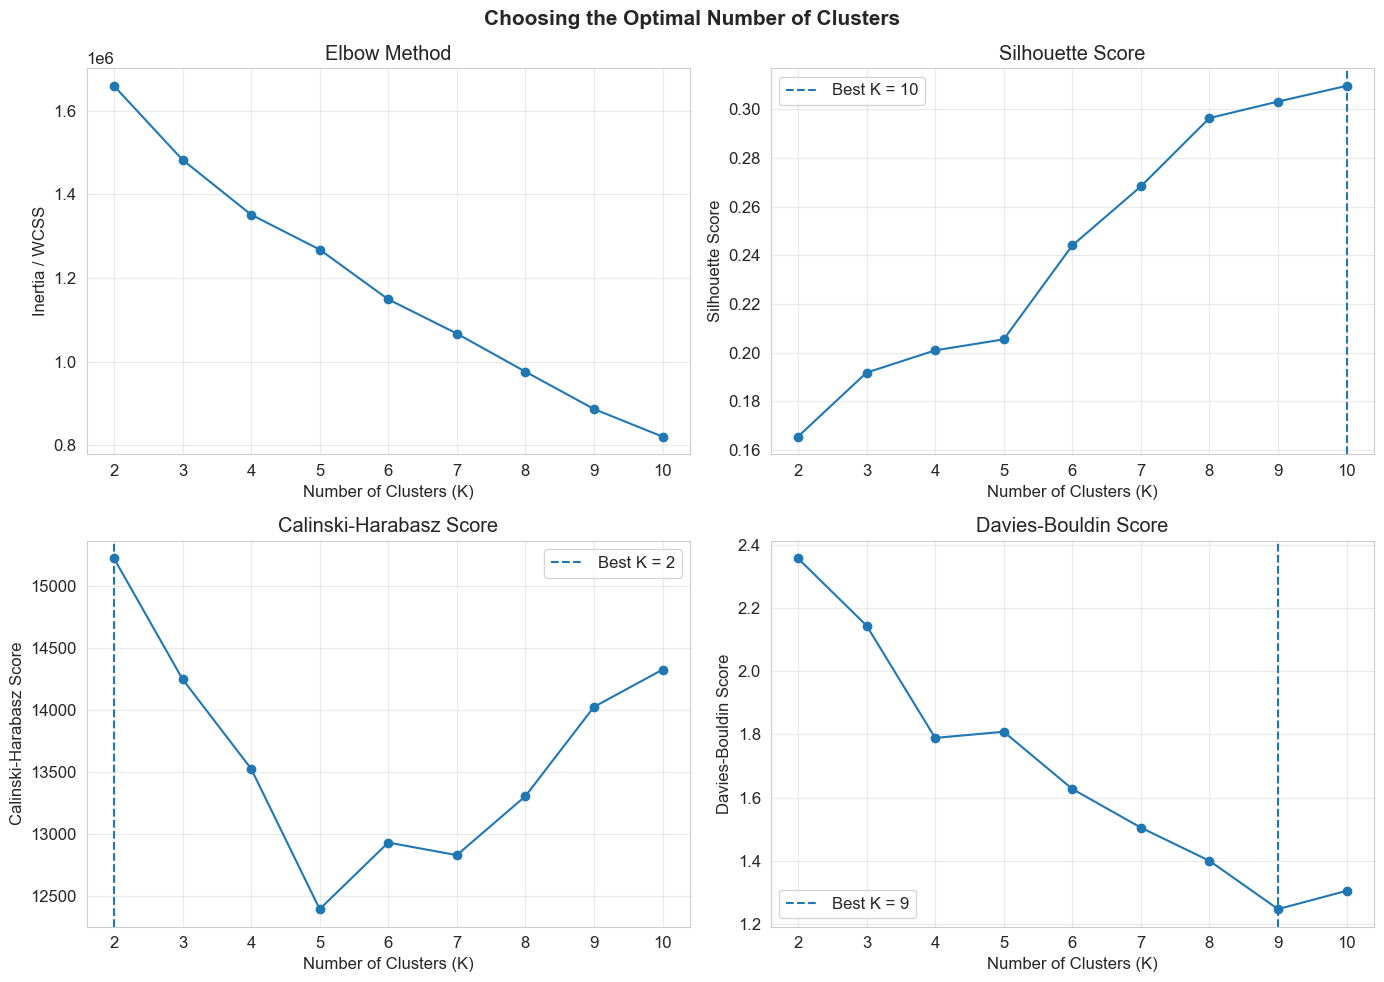


Best K according to Silhouette Score: K = 10
Best K according to Calinski-Harabasz Score: K = 2
Best K according to Davies-Bouldin Score: K = 9


In [22]:
print('Calculating Elbow Method and clustering metrics for K=2..10...')

K_range = range(2,11)

inertia_values = []
silhouette_values = []
calinski_values = []
davies_values = []

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    inertia_values.append(kmeans.inertia_)

    silhouette = silhouette_score(
        X_scaled,
        labels,
        sample_size=10000,
        random_state=RANDOM_STATE
    )

    calinski = calinski_harabasz_score(X_scaled, labels)
    davies = davies_bouldin_score(X_scaled, labels)

    silhouette_values.append(silhouette)
    calinski_values.append(calinski)
    davies_values.append(davies)

    print(
        f'K={k}:'
        f'Inertia={kmeans.inertia_:.0f} | '
        f'Silhouette={silhouette:.4f} | '
        f'Calinski-Harabasz={calinski:.2f} | '
        f'Davies-Bouldin={davies:.4f}'
    )

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Choosing the Optimal Number of Clusters', fontsize=15, fontweight='bold')


axes[0, 0].plot(K_range, inertia_values, marker='o')
axes[0, 0].set_title('Elbow Method')
axes[0, 0].set_xlabel('Number of Clusters (K)')
axes[0, 0].set_ylabel('Inertia / WCSS')
axes[0, 0].grid(True, alpha=0.4)

best_k_silhouette = list(K_range)[np.argmax(silhouette_values)]

axes[0, 1].plot(K_range, silhouette_values, marker='o')
axes[0, 1].axvline(
    x=best_k_silhouette,
    linestyle='--',
    label=f'Best K = {best_k_silhouette}'
)
axes[0, 1].set_title('Silhouette Score')
axes[0, 1].set_xlabel('Number of Clusters (K)')
axes[0, 1].set_ylabel('Silhouette Score')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.4)

best_k_ch = list(K_range)[np.argmax(calinski_values)]

axes[1, 0].plot(K_range, calinski_values, marker='o')
axes[1, 0].axvline(
    x=best_k_ch,
    linestyle='--',
    label=f'Best K = {best_k_ch}'
)
axes[1, 0].set_title('Calinski-Harabasz Score')
axes[1, 0].set_xlabel('Number of Clusters (K)')
axes[1, 0].set_ylabel('Calinski-Harabasz Score')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.4)

best_k_db = list(K_range)[np.argmin(davies_values)]

axes[1, 1].plot(K_range, davies_values, marker='o')
axes[1, 1].axvline(
    x=best_k_db,
    linestyle='--',
    label=f'Best K = {best_k_db}'
)
axes[1, 1].set_title('Davies-Bouldin Score')
axes[1, 1].set_xlabel('Number of Clusters (K)')
axes[1, 1].set_ylabel('Davies-Bouldin Score')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.4)

plt.tight_layout()

plt.savefig(
    'plots/elbow_silhouette.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print(f'\nBest K according to Silhouette Score: K = {best_k_silhouette}')
print(f'Best K according to Calinski-Harabasz Score: K = {best_k_ch}')
print(f'Best K according to Davies-Bouldin Score: K = {best_k_db}')